<div align="center">

<img src="https://raw.githubusercontent.com/winstonsmith1897/DantinoX/main/docs/images/dantinox.png" width="150" alt="DantinoX"/>

</div>

# DantinoX · 03 — Continuous Flow-Matching (ELF recipe)

<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/03_elf_flow_matching.ipynb) &nbsp;
[![PyPI](https://img.shields.io/pypi/v/dantinox?color=7c3aed)](https://pypi.org/project/dantinox/) &nbsp;
[![GitHub](https://img.shields.io/badge/GitHub-DantinoX-181717?logo=github)](https://github.com/winstonsmith1897/DantinoX)

</div>

*Language modeling as continuous flow-matching in T5 embedding space — the ELF recipe.*

---

**You’ll learn**
- `Paradigm(paradigm="continuous")` — unified flow-matching entry point
- Forward process `z_t = t·x + (1−t)·ε` — noise (t=0) → data (t=1)
- `embed_dim=768` to match T5-base; `dim` sets the backbone width independently
- Classifier-free guidance via dedicated control tokens
- Euler ODE sampler

**Runtime** — GPU (T4 or better)

---

In [1]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [2]:
import sys

# Install dantinox only if not already available (skips on local dev machines)
try:
    import dantinox  # noqa: F401
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'uv'], check=True)
    subprocess.run([sys.executable, '-m', 'uv', 'pip', 'install', '--system', '-q', '-U',
                    'dantinox[data,hub,elf,benchmark]', 'flax>=0.12,<0.13', 'jax[cuda12]'],
                   check=True)

# transformers 4.x required — FlaxT5EncoderModel was removed in transformers 5.x
import subprocess

result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'transformers'],
                        capture_output=True, text=True)
version_line = [l for l in result.stdout.splitlines() if l.startswith('Version:')]
current = version_line[0].split()[1] if version_line else '0'
if int(current.split('.')[0]) >= 5:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'transformers==4.44.2'],
                   check=True)
    print('transformers downgraded to 4.44.2 (Flax T5 support)')
else:
    print(f'transformers {current} OK')

  warnings.warn(



  ████                █    █                █   █
  █   █  ███  ████  █████       ████   ███   █ █ 
  █   █ █   █ █   █   █    █    █   █ █   █   █  
  █   █ █  ██ █   █   █    █    █   █ █   █  █ █ 
  ████   ████ █   █   ██   ███  █   █  ███  █   █

  JAX/Flax transformer library  v0.4.7



transformers 4.44.2 OK


In [3]:
import dantinox as dx

dx.doctor()   # environment health check — jax/flax/CUDA alignment, GPU visibility

E0715 11:25:18.748315 2416135 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 29.62GiB (31803604992 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0715 11:25:18.749171 2416135 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 26.66GiB (28623243264 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0715 11:25:18.749863 2416135 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 23.99GiB (25760917504 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0715 11:25:18.750668 2416135 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 21.59GiB (23184824320 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0715 11:25:18.751325 2416135 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 19.43GiB (20866340864 by

DantinoX doctor
  dantinox             0.4.7
  jax                  0.9.2
  jaxlib               0.9.2
  flax                 0.12.6
  optax                0.2.8
  jax-cuda12-plugin    0.10.0
  jax-cuda12-pjrt      0.10.0
  transformers         4.44.2
  datasets             4.8.5
  devices              cuda:0
  ✗ jax-cuda12-plugin 0.10.0 vs jaxlib 0.9.2 — the CUDA plugin must match jaxlib exactly (PJRT errors otherwise); fix: pip install -U "jax[cuda12]"


{'versions': {'dantinox': '0.4.7',
  'jax': '0.9.2',
  'jaxlib': '0.9.2',
  'flax': '0.12.6',
  'optax': '0.2.8',
  'jax-cuda12-plugin': '0.10.0',
  'jax-cuda12-pjrt': '0.10.0',
  'transformers': '4.44.2',
  'datasets': '4.8.5'},
 'problems': ['jax-cuda12-plugin 0.10.0 vs jaxlib 0.9.2 — the CUDA plugin must match jaxlib exactly (PJRT errors otherwise); fix: pip install -U "jax[cuda12]"'],
 'warnings': [],
 'gpu': ['cuda:0'],
 'ok': False}

In [4]:
import os
import urllib.request

if not os.path.exists('tiny_shakespeare.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt',
        'tiny_shakespeare.txt')
    print('Downloaded tiny_shakespeare.txt')

with open('tiny_shakespeare.txt') as f:
    text = f.read()
print(f'Corpus: {len(text):,} characters')

Corpus: 1,115,394 characters


## 1. Configuration

`ModelConfig` parameters for the continuous flow-matching paradigm:

| Parameter | Description | Constraint |
|---|---|---|
| `embed_dim` | Flow-matching space dimension | **Must equal T5 hidden dim** (768 for T5-base) |
| `bottleneck_dim` | Bottleneck between embed and model space | Any size < embed_dim |
| `dim` | Transformer backbone width | Determines `n_heads × head_size` |
| `vocab_size` | Output vocabulary | Auto-set to 32100 for `paradigm="continuous"` |

Set `paradigm="continuous"` in `ModelConfig` — `causal=False` and `vocab_size=32100` are configured automatically.

In [5]:
import jax
from flax import nnx

import dantinox as dx

# embed_dim=768 matches T5-base hidden size
# dim=256 is the transformer backbone (can be smaller than embed_dim)
# vocab_size is auto-set to 32100 (T5 SentencePiece vocabulary, same for all T5 variants)
elf_cfg = dx.ModelConfig(
    paradigm       = "continuous",  # causal=False set automatically
    embed_dim      = 768,           # T5-base hidden size — MUST match T5 output dim
    bottleneck_dim = 128,           # projects 768 → 128 → dim
    dim            = 256,           # transformer hidden dim
    n_heads        = 4,             # head_size auto-computed = 64 ✓
    num_blocks     = 4,
    max_context    = 128,
)

paradigm = dx.Paradigm(elf_cfg)
model    = paradigm.build_model(nnx.Rngs(42))
n_params = sum(x.size for x in jax.tree_util.tree_leaves(nnx.state(model, nnx.Param)))
print(f'ELF model — {n_params / 1e6:.2f}M parameters')
print('Paradigm:', paradigm)
print('vocab_size (auto):', elf_cfg.vocab_size)

ELF model — 30.90M parameters
Paradigm: Paradigm(type='continuous', impl=ContinuousParadigm(embed=768, dim=256, blocks=4))
vocab_size (auto): 32100


## 2. Forward Process

ELF's forward process interpolates linearly between Gaussian noise and clean T5 embeddings:

```
z_t = t·x + (1−t)·ε     ε ~ N(0, I),  t ∈ [0, 1]
```

- `t = 0`: pure noise  
- `t = 1`: clean embedding

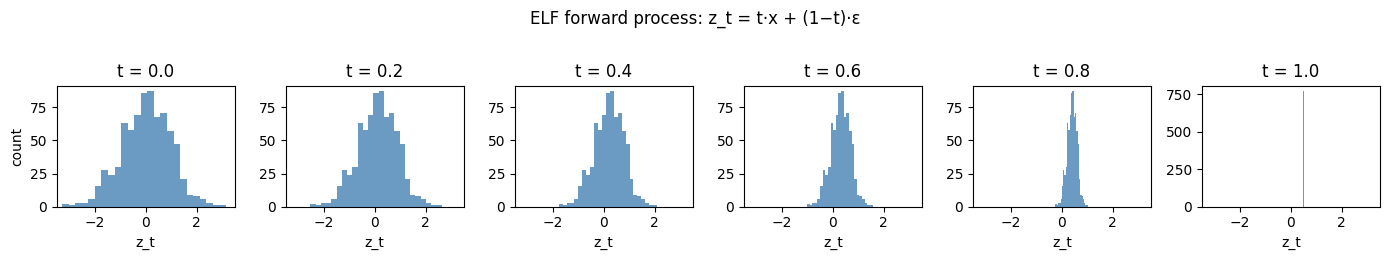

In [6]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

rng = jax.random.PRNGKey(0)
eps = jax.random.normal(rng, (768,))   # noise vector
x   = jnp.ones(768) * 0.5             # mock clean embedding

ts   = np.linspace(0, 1, 6)
fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
for ax, t in zip(axes, ts):
    z_t = t * x + (1 - t) * eps
    ax.hist(np.array(z_t), bins=25, color='steelblue', alpha=0.8)
    ax.set_title(f't = {t:.1f}')
    ax.set_xlim(-3.5, 3.5)
    ax.set_xlabel('z_t')
axes[0].set_ylabel('count')
plt.suptitle('ELF forward process: z_t = t·x + (1−t)·ε', y=1.02)
plt.tight_layout(); plt.show()

## 3. Time Schedule

Training uses a **logit-normal** schedule: concentrates samples in the hard denoising regime near `t ≈ 0.2`.

Train schedule: 65 steps, shape=(65,)


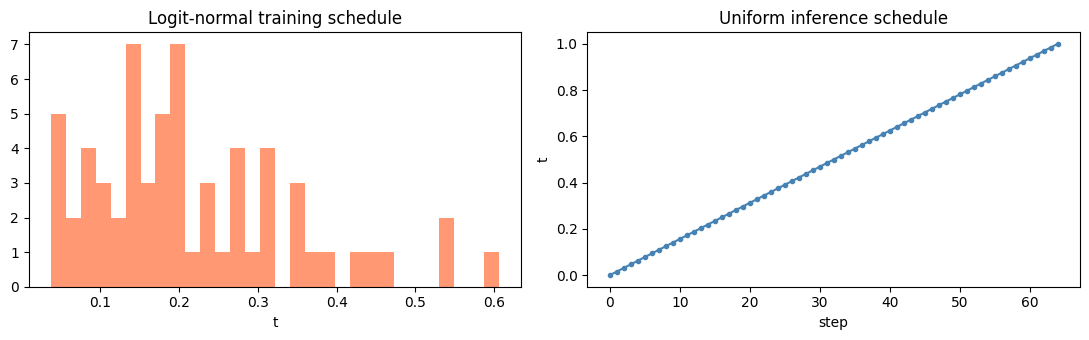

In [7]:
from dantinox.core.diffusion import logit_normal_schedule

# logit_normal_schedule(n) returns n+1 time-points: [0, interiors, 1]
train_ts = logit_normal_schedule(64, pmean=-1.5, pstd=0.8)
infer_ts = jnp.linspace(0.0, 1.0, 65)

print(f'Train schedule: {len(train_ts)} steps, shape={train_ts.shape}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.hist(np.array(train_ts[1:-1]), bins=30, color='coral', alpha=0.8)
ax1.set_xlabel('t'); ax1.set_title('Logit-normal training schedule')
ax2.plot(np.array(infer_ts), marker='.', color='steelblue')
ax2.set_xlabel('step'); ax2.set_ylabel('t'); ax2.set_title('Uniform inference schedule')
plt.tight_layout(); plt.show()

## 4. Training

ELF uses T5-base as a **frozen text encoder**. The `Trainer` automatically:
1. Encodes each batch through T5-base → 768-dim embeddings
2. Normalises the embeddings (channel-wise mean/std, computed once before training)
3. Runs the ELF denoising loss + decoder CE loss

> ⚠️ T5-base (~850 MB) is downloaded on first run. `tokenizer_type` is forced to `"t5"` automatically.

In [8]:
import dantinox as dx

elf_cfg = dx.ModelConfig(
    paradigm="continuous",        # sets causal=False automatically
    dim=256, n_heads=4,           # transformer backbone (head_size auto-computed = 64)
    embed_dim=768,                # must match T5-base hidden size
    bottleneck_dim=128,
    num_blocks=4, max_context=128,
    flow_n_steps=32, flow_cfg_scale=1.5,
)

paradigm  = dx.Paradigm(elf_cfg)
train_cfg = dx.TrainingConfig(lr=1e-3, epochs=1, batch_size=8, optimizer='muon', use_bf16=True)

run_dir = dx.Trainer(paradigm, train_cfg).fit('tiny_shakespeare.txt')
print('Checkpoint saved to:', run_dir)

  [DantinoX]  Continuous flow-matching paradigm detected — tokenizer_type: 'char' → 't5'


  from .autonotebook import tqdm as notebook_tqdm


/home/marco.simoni/miniconda3/envs/dantinox/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


  warnings.warn(



  ──────────────────────────────────────────────────────────────
  continuous  ·  bidirectional
  ──────────────────────────────────────────────────────────────
  run dir       runs/20260715_112526
  parameters    30.9 M  (30,897,152)

  ── model ─────────────────────────────────────────────────────
  256-dim  ·  4h×64  ·  4 blocks  ·  vocab=32,100  ·  ctx=128
  MHA  ·  RoPE  ·  RMSNorm  ·  bidirectional  ·  MLP(×4,SwiGLU)

  ── data ──────────────────────────────────────────────────────
  source        tiny_shakespeare.txt
  tokenizer     t5  ·  32100 vocab
  tokens        341,470  (train 307,323  ·  val 34,147)

  ── training ──────────────────────────────────────────────────
  optimizer     muon  ·  lr=1e-03  ·  cosine  ·  warmup=400
  batch         8
  schedule      1 epoch  ·  300 steps/epoch  ·  300 updates
  precision     bf16
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



...

Epoch 1/1:  98%|█████████▊| 293/300 [01:06<00:00, 18.26it/s, loss=4.3287]

Epoch 1/1:  99%|█████████▉| 298/300 [01:06<00:00, 22.60it/s, loss=4.3287]

  Epoch 1/1  train=4.0936  val=3.7301  ★ best  13.6s (+52.9s compile)  22.6k tok/s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 3.7301
  saved → runs/20260715_112526
  ──────────────────────────────────────────────────────────────



Checkpoint saved to: runs/20260715_112526


## 5. Generation

Generation denoises from Gaussian noise to clean embeddings via an Euler ODE, then decodes:

```
z_0 ~ N(0, I)  →  ODE steps (t: 0 → 1)  →  argmax(W_e^T z_1)  →  tokens
```

In [9]:
import os

from dantinox.utils.tokenizer import load_tokenizer_from_file

elf_model = dx.load(run_dir, paradigm=paradigm)
tokenizer = load_tokenizer_from_file(os.path.join(run_dir, 'tokenizer.json'))

print('ELF flow matching — iterative refinement:')
for step, total, tokens in paradigm.stream(elf_model, max_new_tokens=32, n_steps=32):
    text = tokenizer.decode(tokens[0].tolist())
    print(f'\rStep {step+1:3d}/{total} │ {text}', end='', flush=True)
print()

  warnings.warn(


ELF flow matching — iterative refinement:


Step   1/33 │ ,   moves,RRdungRR,mailRRdungRR, terrace,,,,RR,,,mail, session,,RR,,

Step   2/33 │ ,RR, sessionRRdungRR session solutiiRRdungRR, session   session,,RR,dung, Earth Earth,,RRRR,

Step   3/33 │ ,RR  moves,RRdungRR sessiondungRRdungRR,RR   session,,RR,dung, Earth Earth,, dungRR

...

Step  29/33 │ ,RRRR, Earth Earth Earth Earth,RRRR, Earth, Earth, session session,RRRR,,, session,,,,, Earth Earth

Step  30/33 │ ,RRRR, Earth Earth Earth Earth,,RR, Earth, Earth, session session,RRRR,,, session,,,,, Earth Earth

Step  31/33 │ Earth Earth,, Earth Earth Earth Earth Earth,RR Earth Earth Earth Earth Earth session sessionRRRRRR,,, session,,,,, Earth Earth

Step  32/33 │ Earth Earth, Earth Earth Earth Earth Earth Earth, Earth Earth Earth Earth Earth Earth session session sessionRRRR, session session session,,,,, Earth Earth

Step  33/33 │ I I I I I I I I I Iaaaaaaaaaaaaaaaa I I Isss

## 6. CFG Guidance Scale Ablation

Classifier-Free Guidance scale `w` controls diversity vs. focus:
- `w = 1.0`: no guidance
- `w = 1.5`: mild guidance (recommended default)
- `w ≥ 3.0`: strong guidance (more focused, may reduce diversity)

In [10]:
import jax

for w in (1.0, 1.5, 2.0, 3.0, 5.0):
    toks = paradigm.generate(elf_model, rng=jax.random.PRNGKey(42),
                             max_new_tokens=32, n_steps=32, cfg_scale=w)
    unique = len(set(toks[0].tolist()))
    print(f'cfg_scale={w:.1f}  unique_tokens={unique:3d}  sample={toks[0, :12].tolist()}')

cfg_scale=1.0  unique_tokens=  3  sample=[27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 9]


cfg_scale=1.5  unique_tokens=  3  sample=[27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 9, 9]


cfg_scale=2.0  unique_tokens=  3  sample=[27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 9, 9]


cfg_scale=3.0  unique_tokens=  3  sample=[27, 27, 27, 27, 27, 27, 27, 27, 9, 9, 9, 9]


cfg_scale=5.0  unique_tokens=  4  sample=[9, 9, 9, 9, 9, 27, 27, 9, 9, 9, 9, 9]


## 7. Model Size Ablation

`embed_dim` is fixed at 768 (T5-base), but `model_dim` and `num_blocks` can be varied freely.

In [11]:
size_variants = [
    ('Tiny',   dx.ModelConfig(paradigm="continuous", dim=64,  n_heads=2, embed_dim=768, bottleneck_dim=64,
                               num_blocks=2, max_context=64)),
    ('Small',  dx.ModelConfig(paradigm="continuous", dim=256, n_heads=4, embed_dim=768, bottleneck_dim=128,
                               num_blocks=4, max_context=128)),
    ('Medium', dx.ModelConfig(paradigm="continuous", dim=512, n_heads=8, embed_dim=768, bottleneck_dim=256,
                               num_blocks=8, max_context=256)),
]

for name, cfg in size_variants:
    p = dx.Paradigm(cfg)
    m = p.build_model(nnx.Rngs(0))
    n = sum(x.size for x in jax.tree_util.tree_leaves(nnx.state(m, nnx.Param)))
    print(f'{name:8s}  dim={cfg.dim:4d}  blocks={cfg.num_blocks:2d}  {n/1e6:.2f}M params')

Tiny      dim=  64  blocks= 2  26.20M params


Small     dim= 256  blocks= 4  30.90M params


Medium    dim= 512  blocks= 8  61.22M params


## 8. One-liner API

In [12]:
rd = dx.fit(
    'continuous', 'tiny_shakespeare.txt',
    embed_dim=768, bottleneck_dim=128, dim=256,
    n_heads=4, num_blocks=4,
    max_context=128,
    flow_n_steps=32, flow_cfg_scale=1.5,
    lr=1e-3, epochs=1, batch_size=8, ffn='moe',
)
print('ELF run dir:', rd)

  [DantinoX]  Continuous flow-matching paradigm detected — tokenizer_type: 'char' → 't5'



  ──────────────────────────────────────────────────────────────
  continuous  ·  bidirectional
  ──────────────────────────────────────────────────────────────
  run dir       runs/20260715_112825
  parameters    30.9 M  (30,897,152)

  ── model ─────────────────────────────────────────────────────
  256-dim  ·  4h×64  ·  4 blocks  ·  vocab=32,100  ·  ctx=128
  MHA  ·  RoPE  ·  RMSNorm  ·  bidirectional  ·  MLP(×4,SwiGLU)

  ── data ──────────────────────────────────────────────────────
  source        tiny_shakespeare.txt
  tokenizer     t5  ·  32100 vocab
  tokens        341,470  (train 307,323  ·  val 34,147)

  ── training ──────────────────────────────────────────────────
  optimizer     adamw  ·  lr=1e-03  ·  cosine  ·  warmup=400
  batch         8
  schedule      1 epoch  ·  300 steps/epoch  ·  300 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  ⚠  only 300 optimizer updates — the model will likely be undertrained; lower batch_size or raise epochs


Some weights of the model checkpoint at t5-base were not used when initializing FlaxT5EncoderModel: {('decoder', 'block', '2', 'layer', '1', 'EncDecAttention', 'o', 'kernel'), ('decoder', 'block', '1', 'layer', '0', 'SelfAttention', 'q', 'kernel'), ('decoder', 'block', '2', 'layer', '1', 'EncDecAttention', 'v', 'kernel'), ('decoder', 'block', '8', 'layer', '1', 'EncDecAttention', 'k', 'kernel'), ('decoder', 'block', '2', 'layer', '1', 'EncDecAttention', 'q', 'kernel'), ('decoder', 'block', '5', 'layer', '1', 'EncDecAttention', 'o', 'kernel'), ('decoder', 'block', '4', 'layer', '1', 'EncDecAttention', 'q', 'kernel'), ('decoder', 'block', '2', 'layer', '0', 'SelfAttention', 'k', 'kernel'), ('decoder', 'block', '3', 'layer', '1', 'layer_norm', 'weight'), ('decoder', 'block', '5', 'layer', '0', 'layer_norm', 'weight'), ('decoder', 'block', '8', 'layer', '2', 'DenseReluDense', 'wo', 'kernel'), ('decoder', 'block', '11', 'layer', '2', 'layer_norm', 'weight'), ('decoder', 'block', '5', 'layer

Pre-encoding T5 windows:   0%|          | 0/150 [00:00<?, ?it/s]

...

Epoch 1/1:  97%|█████████▋| 291/300 [00:44<00:00, 32.01it/s, loss=2.2213]

Epoch 1/1:  99%|█████████▊| 296/300 [00:44<00:00, 34.88it/s, loss=2.2213]

  Epoch 1/1  train=2.5319  val=2.2497  ★ best  8.6s (+35.7s compile)  35.8k tok/s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 2.2497
  saved → runs/20260715_112825
  ──────────────────────────────────────────────────────────────



ELF run dir: runs/20260715_112825


---

**Recap** — you learned:
- language modeling in continuous T5 embedding space (ELF recipe)
- `embed_dim` vs backbone `dim`, and classifier-free guidance
- Euler ODE sampling with `flow_n_steps`

**Next →** [04 · Benchmarking & Profiling](04_benchmarking.ipynb) · [Open in Colab](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/04_benchmarking.ipynb)